In [9]:
import xarray as xr
import numpy as np
import string
import seaborn as sns
import os
import math
import matplotlib.pyplot as plt
import gsw
from datetime import datetime, timedelta
import pandas as pd
import importlib
# from gptide import cov
from gptide import GPtideScipy
from gptide import stats as gpstats
from scipy import signal as sg
# from s3fs import S3FileSystem, S3Map
import scipy
import seaborn as sns
from speccy import utils as ut
from scipy import stats
from speccy import sick_tricks as gary
from scipy.special import kv as K_nu
from scipy.special import gamma
from scipy.optimize import minimize
# mle function import
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [10]:
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['font.size'] = 18
plt.rcParams['figure.figsize'] = [10, 10]
#np.set_printoptions(threshold=sys.maxsize)
plt.rcParams['animation.embed_limit'] = 2**128

# Import the model-fit results

In [12]:
from functions import Processing
# Final_df_M1P1_all = pd.read_csv('old Final M1P1 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv')  
# Final_df_M1P2_all = pd.read_csv('old Final M1P2 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv')  

Final_df_M1P1_all = pd.read_csv('Final M1P1 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv')  
Final_df_M1P2_all = pd.read_csv('Final M1P2 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv')  

In [13]:
importlib.reload(Processing)
deep_sites = ['ITFTIS','KIM400'  ]
shallow_sites = ['NWSLYN','NWSBRW','KIM200','NWSROW','PIL200','NWSBAR',]
Final_df_M1P1_all = Processing.Select_df_from_sites(Final_df_M1P1_all,shallow_sites,'M1P1')
Final_df_M1P2_all = Processing.Select_df_from_sites(Final_df_M1P2_all,shallow_sites,'M1P2')
Final_df_M1P2_all['HA_η'] = np.sqrt(Final_df_M1P2_all['HA_var'])
Final_df_M1P1_all['HA_η'] = np.sqrt(Final_df_M1P1_all['HA_var'])
Final_df_M1P2_all['HA_M2'] = np.sqrt(Final_df_M1P2_all['HA_M2_var'])
Final_df_M1P1_all['HA_M2'] = np.sqrt(Final_df_M1P1_all['HA_M2_var'])
Final_df_M1P2_all['HA_S2'] = np.sqrt(Final_df_M1P2_all['HA_S2_var'])
Final_df_M1P1_all['HA_S2'] = np.sqrt(Final_df_M1P1_all['HA_S2_var'])
Final_df_M1P2_all 

,Dict_name,Site,Mode,HA_var,HA_M2_var,HA_S2_var,Start_date,Var_residual,Var_model_fit,Whittle_value,...,τ_S2,γ_S2,η_M2,τ_M2,γ_M2,season,Model_type,HA_η,HA_M2,HA_S2
0,KIM200_P17_0,KIM200,0,82.865685,53.515053,29.603819,2012-02-02,36.569129,37.386724,-2628.685006,...,1.516944e+01,0.992468,2.709889,10.383668,1.003389,Feb-Apr,M1P2,9.103059,7.315398,5.440939
1,KIM200_P17_0,KIM200,1,2.987070,0.799058,1.580629,2012-02-02,30.231599,29.288355,-3169.900505,...,4.006293e+00,1.000531,2.209348,4.215568,1.000279,Feb-Apr,M1P2,1.728314,0.893900,1.257231
2,KIM200_P17_0,KIM200,2,2.000161,1.029660,0.799532,2012-02-02,13.323398,13.278675,-5047.645732,...,6.443074e+00,1.818082,1.885360,0.049008,0.241183,Feb-Apr,M1P2,1.414270,1.014722,0.894165
3,KIM200_P17_1,KIM200,0,84.820789,34.573165,32.213916,2012-04-22,38.370370,36.560821,-3030.428219,...,3.386254e-01,0.210676,4.506571,5.470193,1.862628,May-Jul,M1P2,9.209820,5.879895,5.675730
4,KIM200_P17_1,KIM200,1,14.126349,9.077822,2.416830,2012-04-22,29.897086,29.821509,-2651.669996,...,6.962864e+00,0.990346,2.934970,5.999111,1.003674,May-Jul,M1P2,3.758504,3.012942,1.554616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,PIL200_P66_0,PIL200,1,3.449198,3.156406,0.179919,2014-02-11,33.971262,33.530814,-2030.015902,...,4.051051e+00,1.000975,1.743483,7.771944,0.995964,Feb-Apr,M1P2,1.857202,1.776628,0.424168
218,PIL200_P66_0,PIL200,2,1.170551,1.041852,0.023600,2014-02-11,15.448073,14.558149,-4249.123619,...,3.940070e+00,0.997082,1.310406,8.949017,1.009633,Feb-Apr,M1P2,1.081920,1.020711,0.153622
219,PIL200_P66_1,PIL200,0,81.866274,77.208830,2.404154,2014-05-02,77.026144,74.035162,-1749.328914,...,2.478267e+36,0.067349,6.645758,6.097892,1.545069,May-Jul,M1P2,9.047998,8.786856,1.550533
220,PIL200_P66_1,PIL200,1,5.578341,3.278799,0.764981,2014-05-02,52.123021,56.453659,-982.124884,...,4.463841e-117,1.864732,6.270123,2.400548,0.190859,May-Jul,M1P2,2.361851,1.810745,0.874632


# Cleaning and Processing

In [15]:
from functions import Cov
importlib.reload(Cov)
importlib.reload(Processing)
#M1P1
Drop_df_M1P1, Final_df_M1P1_clean = Processing.Clean_and_Process_DF(Final_df_M1P1_all,model_type = 'M1P1')
#M1P2
Drop_df_M1P2, Final_df_M1P2_clean = Processing.Clean_and_Process_DF(Final_df_M1P2_all,model_type = 'M1P2')

24 (10.81%) of 222 fits are removed
50 (22.52%) of 222 fits are removed
Rows where both T_M2 and T_S2 are NaN:
     T_M2  T_S2
171   NaN   NaN


In [16]:
M1P2_parameter_name = ['Dict_name','Mode','η_c','α_c','η_S2','τ_S2','γ_S2',
                       'η_M2','τ_M2','γ_M2',]
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
Drop_df_M1P2[M1P2_parameter_name].sort_index()

,Dict_name,Mode,η_c,α_c,η_S2,τ_S2,γ_S2,η_M2,τ_M2,γ_M2
8,KIM200_P18_0,2,4.205657,1.191149,1.012462e+00,8.924747e+00,1.995274,3.079548,3.325701e+48,0.005460
14,KIM200_P19_0,2,1.605656,0.736612,3.494986e+00,6.823678e-02,0.998898,1.958312,2.981390e+00,1.001510
31,NWSBAR_P27_0,1,5.143373,0.651503,5.154563e-02,8.660234e-01,1.001109,8.164995,1.511878e-01,1.004135
32,NWSBAR_P27_0,2,2.714644,0.500000,5.948308e+00,3.315846e+00,0.986106,10.778331,1.098219e-01,0.995002
42,NWSBAR_P29_1,0,2.742396,1.272234,1.762522e+00,4.270348e-02,0.998770,4.233810,1.016895e+01,1.012870
59,NWSBAR_P33_0,2,2.493743,0.676867,5.389423e+00,6.809968e-02,1.036661,5.319370,4.969635e+00,0.983798
75,NWSBRW_P37_0,0,6.071659,0.841658,4.331145e+00,3.343240e+01,0.770049,6.979256,1.257056e+01,1.579177
78,NWSBRW_P37_1,0,7.465155,0.991285,2.592965e+00,7.534292e+00,1.001877,7.662470,4.703513e+01,0.994389
81,NWSBRW_P38_0,0,7.026733,0.839580,3.955960e+00,2.402078e+01,0.993261,11.092126,1.428438e+03,0.989401
84,NWSBRW_P39_0,0,6.168335,0.929324,4.375993e+00,7.196986e+00,2.000000,9.132292,3.716557e+11,1.999993


In [17]:
importlib.reload(Processing)
P2_parameter_name = ['η_S2','τ_S2','γ_S2','T_S2','η_M2','τ_M2','γ_M2','T_M2',]
median_T_M1P2 = Processing.Calc_Parameter_median_and_std(Final_df_M1P2_clean, P2_parameter_name,by_mode=True)
median_T_M1P2

η_S2                τ_S2               γ_S2  \
Site   Mode                                                             
NWSLYN 1     0.52471279 (0.86)    6.9513997 (2.13)  0.99769715 (0.01)   
       2     0.67663663 (0.93)   6.67806831 (6.97)    1.0001062 (0.0)   
       3             0.0 (nan)           nan (nan)          nan (nan)   
NWSBRW 1     3.22325395 (1.63)  14.71534011 (7.18)  0.99386841 (0.56)   
       2      1.65772119 (1.2)   4.75755207 (3.56)   0.99885535 (0.0)   
       3     1.29256924 (1.03)   9.10169925 (7.02)  1.00024407 (0.27)   
KIM200 1     1.69407938 (1.26)  11.99096411 (3.04)  0.99631122 (0.01)   
       2     1.96464003 (1.28)    4.00629283 (1.8)   0.99961534 (0.0)   
       3     0.83949862 (0.72)   1.81078723 (4.62)  1.00224746 (0.31)   
NWSROW 1     1.62282553 (1.03)  10.20882344 (3.16)         2.0 (0.53)   
       2     1.44311282 (0.66)   5.94109555 (6.37)  0.99801825 (0.42)   
       3     0.95188749 (0.44)   4.27944274 (2.29)  1.00211418 (0.42)   
PIL200 1     3.04174711 (1.45)  10.38944416 (3.86)   0.9978697 (0.13)   
       2     2.18263367 (1.54)   2.82802682 (1.59)   0.99814973 (0.0)   
       3     1.15871744 (1.07)    1.7465096 (1.91)   0.99839501 (0.0)   
NWSBAR 1     1.18563988 (1.28)    7.5227841 (5.18)  1.00055926 (0.38)   
       2     0.82493341 (1.23)   1.87362211 (3.72)  1.00219997 (0.34)   
       3     0.81849298 (1.66)   4.04555739 (1.66)   1.00139361 (0.3)   

                           T_S2               η_M2                τ_M2  \
Site   Mode                                                              
NWSLYN 1      6.96412901 (2.11)  3.48172346 (0.66)   9.23281092 (8.74)   
       2      6.67987126 (6.97)  2.85380139 (2.68)   7.82454523 (4.28)   
       3              nan (nan)   1.80226887 (nan)    0.19799581 (nan)   
NWSBRW 1     16.06881341 (6.98)  8.26108548 (2.08)  10.21572882 (7.86)   
       2      4.76282325 (3.56)  3.46631826 (0.74)   4.62865168 (3.54)   
       3      9.10314959 (6.98)  2.62278071 (0.86)   7.73497316 (7.03)   
KIM200 1     12.00980204 (3.05)  4.47059423 (1.18)   9.89677946 (3.67)   
       2      4.00539518 (1.81)  3.45312271 (0.92)   3.09736125 (1.57)   
       3      1.80907643 (4.57)  2.00553298 (0.35)    3.81429039 (5.8)   
NWSROW 1      9.04733421 (3.08)  5.30512007 (1.27)   8.02475978 (4.95)   
       2      5.94702644 (5.51)    2.560085 (1.07)     6.472472 (4.88)   
       3       4.02793542 (2.3)  1.48968709 (1.09)   4.83973321 (3.81)   
PIL200 1     10.40938295 (5.13)  6.27122609 (2.13)    9.5222936 (7.07)   
       2       2.8295361 (1.59)   4.2081387 (1.61)   3.56892454 (2.24)   
       3      1.74265369 (1.91)   2.01495739 (0.6)   3.97727633 (2.63)   
NWSBAR 1      7.52055342 (6.02)   3.8698905 (0.85)    6.21022324 (4.3)   
       2      1.87179574 (3.73)  1.71131583 (1.67)   4.15812432 (2.08)   
       3      3.89853874 (1.73)  1.55922372 (2.79)   4.19128632 (2.18)   

                          γ_M2               T_M2  
Site   Mode                                        
NWSLYN 1     0.99640759 (0.47)   8.47320897 (9.0)  
       2     0.99373828 (0.45)  8.50450848 (4.54)  
       3      0.37405438 (nan)   0.80110023 (nan)  
NWSBRW 1     1.40960312 (0.41)  9.30098595 (8.26)  
       2     0.99981375 (0.34)  4.65317777 (3.58)  
       3      0.9995943 (0.41)  7.61546697 (7.15)  
KIM200 1     1.00046845 (0.44)  9.95466798 (3.87)  
       2     0.99977913 (0.48)  3.09698306 (1.45)  
       3     0.99681254 (0.34)  5.00413363 (5.26)  
NWSROW 1     1.94109099 (0.45)  7.65818883 (5.13)  
       2     0.99875213 (0.54)  6.76037385 (4.57)  
       3     1.00116086 (0.09)   4.82636473 (3.8)  
PIL200 1     0.99886959 (0.24)  9.50625834 (7.19)  
       2     0.99712159 (0.37)  4.31984842 (1.75)  
       3     1.00822097 (0.23)  3.78209064 (2.67)  
NWSBAR 1     1.54673303 (0.44)   5.67175101 (4.3)  
       2     1.01357496 (0.48)  4.17482738 (1.89)  
       3     1.00068068 (0.32)  4.19293143 (2.22)

        Dict_name    Site  Mode    HA_var  HA_M2_var  HA_S2_var  Start_date  \
168  PIL200_P66_0  PIL200     2  3.449198   3.156406   0.179919  2014-02-11   

     Var_residual  Var_model_fit  Whittle_value       η_c       α_c      η_S2  \
168     33.971262      33.530814   -2030.015902  6.186834  0.939052  2.182634   

         τ_S2      γ_S2      η_M2      τ_M2      γ_M2   season Model_type  \
168  4.051051  1.000975  1.743483  7.771944  0.995964  Feb-Apr       M1P2   

         HA_η     HA_M2     HA_S2  Subset_Var   HA_var%  Var_model_fit%  \
168  1.857202  1.776628  0.424168    37.42046  9.217412       98.703469   

         2α_c      T_S2      T_M2     T_D2  
168  1.878103  4.049384  7.785313  5.70841  


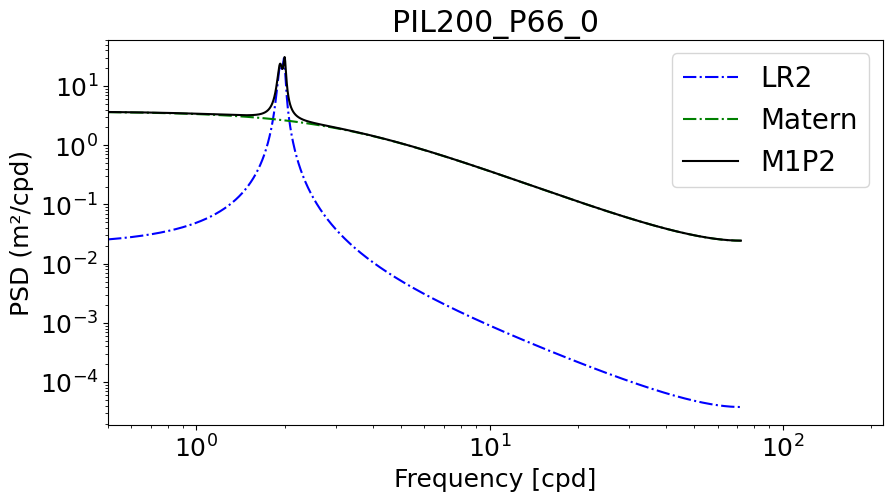

In [18]:
from functions import Plot_figure
importlib.reload(Plot_figure)
importlib.reload(Cov)
plt.rcParams['figure.figsize'] = [10, 5]
plt = Plot_figure.Plot_each_component_model_fit(Final_df_M1P2_clean,'PIL200_P66_0',mode = 2, model_type = 'M1P2')
plt.ylabel("PSD (m²/cpd)")
plt.show()

# Parameter and Var medium and sd

In [20]:
M1P1_parameter_name = ['η_c','2α_c', 'η_D2','τ_D2','γ_D2',
                       'T_D2','Var_model_fit%']
importlib.reload(Processing)
medium_std_P1 = Processing.Calc_Parameter_median_and_std(Final_df_M1P1_clean, M1P1_parameter_name,by_mode=True)
medium_std_P1.xs(1, level='Mode') #mode-1 only

,η_c,2α_c,η_D2,τ_D2,γ_D2,T_D2,Var_model_fit%
Site,,,,,,,
NWSLYN,4.52741287 (0.78),1.42660707 (0.22),3.85404275 (0.67),4.53638927 (0.58),2.0 (0.37),4.12486502 (0.5),100.51884305 (5.35)
NWSBRW,6.71483136 (1.01),1.78073808 (0.15),8.97909409 (1.39),5.28459181 (0.75),2.0 (0.04),4.68334755 (0.67),97.06572829 (5.35)
KIM200,5.42592013 (0.42),1.79662461 (0.17),4.67357105 (1.14),4.37751655 (2.06),2.0 (0.41),3.89566674 (2.22),103.12852025 (1.52)
NWSROW,5.26578151 (0.64),1.78760839 (0.2),6.11645065 (1.09),4.51517124 (0.87),1.99519673 (0.27),4.00164849 (0.81),99.27481763 (4.46)
PIL200,7.01708434 (1.26),1.8980093 (0.09),7.01572311 (2.02),3.98670308 (2.2),1.74245138 (0.45),3.56536899 (2.38),99.54028673 (2.67)
NWSBAR,5.17815007 (1.08),1.94701192 (0.16),4.28368274 (0.78),4.0204063 (1.04),1.95758138 (0.44),3.61999733 (1.1),100.72064873 (2.82)


In [21]:
Final_df_M1P2_clean['Var_model_fit%'].std()

3.463722028488719

In [22]:
importlib.reload(Processing)
M1P2_parameter_name = ['HA_M2_η','HA_S2_η','η_c','η_M2','η_S2',
                       '2α_c', 'T_M2', 'T_S2','Var_model_fit%']
medium_std_P2 = Processing.Calc_Parameter_median_and_std(Final_df_M1P2_clean, M1P2_parameter_name, by_mode=True)
medium_std_P2#.xs(1, level='Mode') #mode-1 only

η_c               η_M2               η_S2  \
Site   Mode                                                            
NWSLYN 1      4.52363469 (0.8)  3.48172346 (0.66)  0.52471279 (0.86)   
       2     4.15148703 (1.56)  2.85380139 (2.68)  0.67663663 (0.93)   
       3      3.29262778 (nan)   1.80226887 (nan)          0.0 (nan)   
NWSBRW 1     6.89037498 (1.17)  8.26108548 (2.08)  3.22325395 (1.63)   
       2     5.52865518 (0.47)  3.46631826 (0.74)   1.65772119 (1.2)   
       3     4.64891593 (0.83)  2.62278071 (0.86)  1.29256924 (1.03)   
KIM200 1      5.41121668 (0.4)  4.47059423 (1.18)  1.69407938 (1.26)   
       2     5.79602918 (0.38)  3.45312271 (0.92)  1.96464003 (1.28)   
       3     3.73653554 (0.45)  2.00553298 (0.35)  0.83949862 (0.72)   
NWSROW 1      5.2786805 (0.59)  5.30512007 (1.27)  1.62282553 (1.03)   
       2      4.4368451 (0.57)    2.560085 (1.07)  1.44311282 (0.66)   
       3     2.84520042 (0.43)  1.48968709 (1.09)  0.95188749 (0.44)   
PIL200 1     6.99339272 (1.28)  6.27122609 (2.13)  3.04174711 (1.45)   
       2     6.31820059 (0.67)   4.2081387 (1.61)  2.18263367 (1.54)   
       3     4.25888922 (0.54)   2.01495739 (0.6)  1.15871744 (1.07)   
NWSBAR 1     5.25681204 (1.04)   3.8698905 (0.85)  1.18563988 (1.28)   
       2     4.86329653 (0.94)  1.71131583 (1.67)  0.82493341 (1.23)   
       3     3.26242793 (2.85)  1.55922372 (2.79)  0.81849298 (1.66)   

                          2α_c               T_M2                T_S2  \
Site   Mode                                                             
NWSLYN 1     1.49766628 (0.27)   8.47320897 (9.0)   6.96412901 (2.11)   
       2      1.73494085 (0.1)  8.50450848 (4.54)   6.67987126 (6.97)   
       3      2.18373137 (nan)   0.80110023 (nan)           nan (nan)   
NWSBRW 1     1.65990282 (0.14)  9.30098595 (8.26)  16.06881341 (6.98)   
       2      1.89872555 (0.1)  4.65317777 (3.58)   4.76282325 (3.56)   
       3     1.93558115 (0.13)  7.61546697 (7.15)   9.10314959 (6.98)   
KIM200 1     1.79693615 (0.18)  9.95466798 (3.87)  12.00980204 (3.05)   
       2     1.92673303 (0.16)  3.09698306 (1.45)   4.00539518 (1.81)   
       3     1.92674003 (0.23)  5.00413363 (5.26)   1.80907643 (4.57)   
NWSROW 1     1.77546224 (0.21)  7.65818883 (5.13)   9.04733421 (3.08)   
       2     1.83583834 (0.17)  6.76037385 (4.57)   5.94702644 (5.51)   
       3     1.81731642 (0.18)   4.82636473 (3.8)    4.02793542 (2.3)   
PIL200 1     1.89426215 (0.09)  9.50625834 (7.19)  10.40938295 (5.13)   
       2     1.91534124 (0.22)  4.31984842 (1.75)    2.8295361 (1.59)   
       3     1.92081787 (0.13)  3.78209064 (2.67)   1.74265369 (1.91)   
NWSBAR 1     1.92222294 (0.14)   5.67175101 (4.3)   7.52055342 (6.02)   
       2      1.70522109 (0.1)  4.17482738 (1.89)   1.87179574 (3.73)   
       3     1.86111086 (0.16)  4.19293143 (2.22)   3.89853874 (1.73)   

                  Var_model_fit%  
Site   Mode                       
NWSLYN 1       97.09244249 (6.1)  
       2      97.76808138 (2.58)  
       3       98.63570752 (nan)  
NWSBRW 1       99.65863794 (2.5)  
       2      101.50160324 (2.4)  
       3     103.92710091 (3.22)  
KIM200 1     101.49549703 (2.74)  
       2       99.9440083 (1.73)  
       3      97.81329539 (1.19)  
NWSROW 1      98.01331869 (2.72)  
       2       98.42915407 (2.2)  
       3      95.86625595 (2.02)  
PIL200 1      99.40697834 (1.81)  
       2      98.70346854 (3.69)  
       3      96.19913895 (1.98)  
NWSBAR 1     102.09581698 (1.99)  
       2     101.71805996 (2.64)  
       3      98.69821533 (1.64)

In [23]:
P2_parameter_name = ['Dict_name','η_S2','τ_S2','γ_S2','η_M2','τ_M2','γ_M2','Var_model_fit%']
medium_std_P2 = Processing.Calc_Parameter_median_and_std(Final_df_M1P2_clean, P2_parameter_name, by_mode=True)
medium_std_P2.xs(1, level='Mode') #mode-1 only

,η_S2,τ_S2,γ_S2,η_M2,τ_M2,γ_M2,Var_model_fit%
Site,,,,,,,
NWSLYN,0.52471279 (0.86),6.9513997 (2.13),0.99769715 (0.01),3.48172346 (0.66),9.23281092 (8.74),0.99640759 (0.47),97.09244249 (6.1)
NWSBRW,3.22325395 (1.63),14.71534011 (7.18),0.99386841 (0.56),8.26108548 (2.08),10.21572882 (7.86),1.40960312 (0.41),99.65863794 (2.5)
KIM200,1.69407938 (1.26),11.99096411 (3.04),0.99631122 (0.01),4.47059423 (1.18),9.89677946 (3.67),1.00046845 (0.44),101.49549703 (2.74)
NWSROW,1.62282553 (1.03),10.20882344 (3.16),2.0 (0.53),5.30512007 (1.27),8.02475978 (4.95),1.94109099 (0.45),98.01331869 (2.72)
PIL200,3.04174711 (1.45),10.38944416 (3.86),0.9978697 (0.13),6.27122609 (2.13),9.5222936 (7.07),0.99886959 (0.24),99.40697834 (1.81)
NWSBAR,1.18563988 (1.28),7.5227841 (5.18),1.00055926 (0.38),3.8698905 (0.85),6.21022324 (4.3),1.54673303 (0.44),102.09581698 (1.99)


In [24]:
df_sites = Final_df_M1P2_clean.copy()

# Parameter Variability at each site and each mode

In [26]:
from functions import Processing
importlib.reload(Processing)
ds_dictionary,A_n_dict,Time_dict, Start_date_dict = Processing.Read_PL3_data('PL3 Stacked data_mode_3 - density fit - single_tanh', 
                                                                              percentage=0.80,window_size_days = 80)
Site_names,Lat_list,Lon_list = Processing.Extract_site_info(ds_dictionary)
ds_dictionary_clean = {key: ds_dictionary[key] for key in ds_dictionary if key in A_n_dict}

There are 67 raw PL3 data (no windowing)
NWSBAR_P29_0 has over-fitting 101.47357244574802%
NWSBAR_P30_1 has over-fitting 102.46347314784029%
NWSBAR_P32_0 has over-fitting 137.51932448688592%
NWSBAR_P34_0 has over-fitting 103.38161762159496%
NWSBAR_P36_0 has over-fitting 108.48260027019856%
NWSLYN_P46_0 has over-fitting 101.09968913297043%
NWSLYN_P47_1 has over-fitting 108.76896340784081%
NWSLYN_P48_0 has over-fitting 111.87182891022606%
NWSLYN_P52_0 has over-fitting 110.91010000579462%
NWSLYN_P52_1 has over-fitting 101.7275860100229%
NWSLYN_P53_1 has over-fitting 104.06032312745438%
NWSROW_P55_1 has over-fitting 153.33321424770907%
ITFTIS_P0_0: 5472 (23.75%) NaN values. Dataset excluded.
ITFTIS_P4_0 mode 3 has 2 amplitudes > 100m. Setting them to NaN.
ITFTIS_P5_0: 3132 (13.59%) NaN values. Dataset excluded.
ITFTIS_P6_0: 6078 (26.38%) NaN values. Dataset excluded.
ITFTIS_P7_1: 8896 (38.61%) NaN values. Dataset excluded.
ITFTIS_P7_2: 17065 (74.06%) NaN values. Dataset excluded.
ITFTIS_P8

In [27]:
# shallow_lat = [Lat_list[Site_names.index(site)] for site in shallow_sites if site in Site_names]
# shallow_lon = [Lon_list[Site_names.index(site)] for site in shallow_sites if site in Site_names]
# importlib.reload(Plot_figure)
# Bathmetry_file  = 'gebco_2023_n-7.6245_s-24.5874_w109.6436_e135.7471.nc'
# M2tide_SSH_file = 'HRET_v8.1_compressed.nc'
# plot_map,ax_map = Plot_figure.Plot_map(Bathmetry_file,M2tide_SSH_file,shallow_sites,shallow_lat, shallow_lon)

# plot_map.savefig('mooring map.pdf', bbox_inches='tight')

## Compute the energy from the obs 

In [38]:
import pickle
with open("ϵ_dict.pkl", "rb") as f:
    ϵ_dict = pickle.load(f) #NPL component displacement

$$APE_n = \sum_m\frac{1}{2}\rho_0\zeta^2\int_{-H}^{0}N^2\Phi^2_m \,dz$$

In [40]:
importlib.reload(Processing)
df_sites = Final_df_M1P2_clean.copy()
APE_dict,APE_obs_avg_list,APE_NPL_avg_list,APE_c_avg_list,APE_HA_avg_list = Processing.Compute_APE(ds_dictionary_clean,Time_dict, ϵ_dict, df_sites,)
# df_sites["APE_obs"] = APE_obs_avg_list
df_sites["APE_NPL"] = APE_NPL_avg_list #just M2 and S2
df_sites["APE_PL"] = APE_HA_avg_list
df_sites['APE_c']  = APE_c_avg_list
df_sites['APE_total'] = df_sites["APE_NPL"]+df_sites["APE_PL"]+df_sites['APE_c'] 
df_sites['APE_c\%']   = df_sites["APE_c"]/df_sites['APE_total']*100 
df_sites['APE_NPL\%'] = df_sites["APE_NPL"]/df_sites['APE_total']*100
df_sites['APE_NPL-T\%'] = df_sites["APE_NPL"]/(df_sites["APE_NPL"]+df_sites["APE_PL"])*100
df_sites

,Dict_name,Site,Mode,HA_var,HA_M2_var,HA_S2_var,Start_date,Var_residual,Var_model_fit,Whittle_value,η_c,α_c,η_S2,τ_S2,γ_S2,η_M2,τ_M2,γ_M2,season,Model_type,HA_η,HA_M2,HA_S2,Subset_Var,HA_var%,Var_model_fit%,2α_c,T_S2,T_M2,T_D2,APE_NPL,APE_PL,APE_c,APE_total,APE_c\%,APE_NPL\%,APE_NPL-T\%
0,KIM200_P17_0,KIM200,1,82.865685,53.515053,29.603819,2012-02-02,36.569129,37.386724,-2628.685006,5.641579,0.963597,2.938800e+00,15.169436,0.992468,2.709889,1.038367e+01,1.003389,Feb-Apr,M1P2,9.103059,7.315398,5.440939,119.434814,69.381517,102.235753,1.927194,15.218470,10.368888,12.891943,141.498880,735.994765,281.823014,1159.316659,24.309408,12.205369,16.125345
1,KIM200_P17_0,KIM200,2,2.987070,0.799058,1.580629,2012-02-02,30.231599,29.288355,-3169.900505,5.296569,1.006069,2.373395e+00,4.006293,1.000531,2.209348,4.215568e+00,1.000279,Feb-Apr,M1P2,1.728314,0.893900,1.257231,33.218669,8.992143,96.879941,2.012137,4.005395,4.215072,4.106481,83.176088,18.825266,221.927266,323.928620,68.511163,25.677289,81.544102
2,KIM200_P17_0,KIM200,3,2.000161,1.029660,0.799532,2012-02-02,13.323398,13.278675,-5047.645732,3.872589,1.213797,1.162189e+00,6.443074,1.818082,1.885360,4.900754e-02,0.241183,Feb-Apr,M1P2,1.414270,1.014722,0.894165,15.323559,13.052848,99.664330,2.427593,5.727059,1.470276,3.093609,36.680940,13.678453,112.145162,162.504554,69.010473,22.572253,72.838328
3,KIM200_P17_1,KIM200,1,84.820789,34.573165,32.213916,2012-04-22,38.370370,36.560821,-3030.428219,4.923227,0.897472,4.096303e-04,NaN,NaN,4.506571,5.470193e+00,1.862628,May-Jul,M1P2,9.209820,5.879895,5.675730,123.191159,68.852984,95.283994,1.794944,NaN,4.857413,4.857413,156.105216,513.354625,186.305124,855.764965,21.770595,18.241599,23.318085
4,KIM200_P17_1,KIM200,2,14.126349,9.077822,2.416830,2012-04-22,29.897086,29.821509,-2651.669996,5.265713,0.895101,1.648753e+00,6.962864,0.990346,2.934970,5.999111e+00,1.003674,May-Jul,M1P2,3.758504,3.012942,1.554616,44.023435,32.088249,99.747209,1.790201,6.991833,5.989860,6.350267,64.169859,65.088393,157.008106,286.266359,54.846859,22.416137,49.644690
5,KIM200_P17_1,KIM200,3,2.562702,1.776027,0.162825,2012-04-22,11.849651,11.489544,-4744.615963,3.600482,0.911545,5.796229e-01,12.562726,0.998345,1.583792,2.097482e+00,0.996506,May-Jul,M1P2,1.600844,1.332677,0.403516,14.412352,17.781287,96.961032,1.823091,12.571543,2.100604,4.905981,13.863532,9.450043,63.184502,86.498077,73.047291,16.027561,59.465493
6,KIM200_P18_0,KIM200,1,50.598917,29.656720,17.974368,2012-08-11,39.816180,39.758008,-1813.505167,5.633303,0.764327,0.000000e+00,NaN,NaN,4.438405,3.195709e+00,1.993460,Aug-Oct,M1P2,7.113292,5.445798,4.239619,90.415097,55.962907,99.853898,1.528654,NaN,2.832296,2.832296,144.880961,350.306238,233.390754,728.577954,32.033738,19.885444,29.257816
7,KIM200_P18_0,KIM200,2,13.720091,10.485973,2.446863,2012-08-11,44.985782,43.258086,-1825.849385,6.296604,0.928240,2.280527e+00,5.516610,1.000979,3.424700,2.180786e+00,0.989993,Aug-Oct,M1P2,3.704064,3.238205,1.564245,58.705873,23.370900,96.159462,1.856481,5.514332,2.190200,3.518941,104.118539,79.539155,243.837179,427.494873,57.038621,24.355506,56.691629
8,KIM200_P18_1,KIM200,1,84.778349,70.192139,5.724716,2012-10-30,58.790227,59.239572,-3392.045000,5.028983,1.003373,2.149462e+00,9.252004,0.996279,6.145442,1.492720e+01,0.996948,Nov-Jan,M1P2,9.207516,8.378075,2.392638,143.568576,59.050769,100.764319,2.006746,9.266667,14.946576,13.474739,396.624731,710.376990,236.652469,1343.654190,17.612602,29.518364,35.828737
9,KIM200_P18_1,KIM200,2,4.742095,0.577640,3.468290,2012-10-30,48.467945,48.649729,-2232.365973,5.823435,1.168738,9.817049e-95,NaN,NaN,5.587113,7.845586e-01,0.448270,Nov-Jan,M1P2,2.177635,0.760027,1.862334,53.210040,8.912030,100.375060,2.337475,NaN,1.961678,1.961678,277.798465,36.005874,301.795935,615.600274,49.024659,45.126436,88.526011


## Variability with modes

In [42]:
  # Select only relevant columns
parameter_cols = [ 'η_S2','τ_S2','γ_S2','η_M2','τ_M2','γ_M2',]
parameter_cols = ['η_c','η_S2','η_M2','T_S2','T_M2','2α_c',]
# Group by mode and compute average and std
parameter_summary = (df_sites.groupby(["Mode"])[parameter_cols].agg(['median']))
# Display clean table
parameter_summary

,η_c,η_S2,η_M2,T_S2,T_M2,2α_c
,median,median,median,median,median,median
Mode,,,,,,
1,5.444527,1.750016,4.853367,9.623202,8.307168,1.850753
2,5.474168,1.397825,3.308879,3.876465,4.466888,1.831828
3,3.975958,0.997280,2.052257,4.415503,5.420369,1.925988


In [43]:
# Select only relevant columns
parameter_cols = ["APE_NPL", "APE_PL", "APE_c","APE_NPL\%","APE_c\%","APE_NPL-T\%", ]
# Group by mode and compute average and std
parameter_summary = (df_sites.groupby("Mode")[parameter_cols].agg(['median', 'std']).round(2))
# Display clean table
parameter_summary

APE_NPL          APE_PL            APE_c         APE_NPL\%         \
      median     std  median      std  median     std    median    std   
Mode                                                                     
1     218.14  192.39  500.15  1017.32  229.99  103.28     23.14  10.63   
2      83.96   80.54   28.49    60.45  177.92   80.39     26.10  11.89   
3      37.53   50.96   16.43   115.61  102.96   56.63     22.64  10.12   

     APE_c\%        APE_NPL-T\%         
      median    std      median    std  
Mode                                    
1      24.93  12.99       32.74  19.59  
2      55.75  14.45       71.37  18.95  
3      63.76  16.83       70.16  23.54

In [44]:
quantile_summary = (
    df_sites
    .groupby(['Site','Mode'], observed=True)[parameter_cols]
    .agg(['median',
          ('p25', lambda x: x.quantile(0.25)),
          ('p75', lambda x: x.quantile(0.75))]))
    
for col in parameter_cols:
    qs = quantile_summary[col]
    quantile_summary[(col, 'IQR_percent')] = ((qs['p75'] - qs['p25']) / qs['median'] * 100 )
# Keep only the IQR_percent columns
iqr_only_cols = [(col, 'IQR_percent') for col in parameter_cols]
iqr_summary = quantile_summary[iqr_only_cols]

# Optional: flatten MultiIndex for cleaner display
iqr_summary.columns = [col[0] for col in iqr_summary.columns]

quantile_summary
iqr_summary

APE_NPL      APE_PL      APE_c  APE_NPL\%    APE_c\%  \
Site   Mode                                                            
NWSLYN 1       8.351014   54.344058  46.435999  32.842284  46.429555   
       2     126.695675  776.564374  37.484410  53.860894  22.912999   
       3       0.000000    0.000000   0.000000   0.000000   0.000000   
NWSBRW 1      43.766855   29.349555  36.310865  29.019829  47.993608   
       2      41.813565  186.976080  23.682432  47.180608  24.431045   
       3      56.337560  130.223219  33.882618  39.468891  47.523393   
KIM200 1      71.053890   27.455874  18.597188  59.896386  32.703815   
       2      81.199899   42.906361  26.855267  48.840000   9.514877   
       3      58.381640   94.109562  43.128812  35.604258   9.641552   
NWSROW 1      40.182278   52.237688  25.980584  65.915988  13.810722   
       2      50.201184   90.592548  48.372045  42.313113  26.118217   
       3      48.798096  171.539905  43.953515  68.487516  43.772827   
PIL200 1      60.470075   34.320228  38.172029  55.410150  21.880036   
       2      51.038830   57.735622  58.555088  30.657082  23.776629   
       3      92.564892   84.363029  28.635811  77.203590  30.643902   
NWSBAR 1      64.576163   80.421881  24.334868  32.388493  23.442362   
       2      46.228721   85.514169  31.806897  48.280397   9.804220   
       3     602.456579  126.729986  92.423259  75.011205  31.006689   

             APE_NPL-T\%  
Site   Mode               
NWSLYN 1       85.823628  
       2       15.174247  
       3        0.000000  
NWSBRW 1       28.368424  
       2       53.634242  
       3       92.244857  
KIM200 1       70.585726  
       2       32.979700  
       3       25.504350  
NWSROW 1       64.801472  
       2       39.517303  
       3       53.568855  
PIL200 1       67.383902  
       2       10.499505  
       3        8.154196  
NWSBAR 1       43.339070  
       2       29.322812  
       3       27.435012

In [45]:
df_sites.columns = (df_sites.columns.str.replace("S2", "S_2", regex=False)
                             .str.replace("M2", "M_2", regex=False))

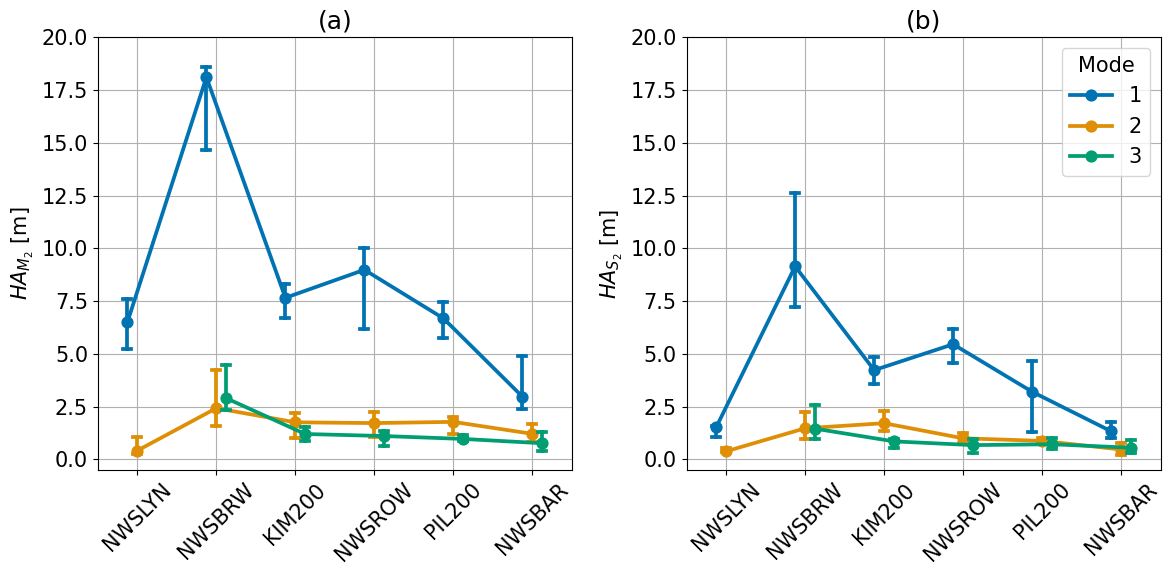

In [46]:
importlib.reload(Plot_figure)
plt.rcParams['font.size'] = 15
# Parameters and units
parameters = ['HA_M_2','HA_S_2']
parameter_units = ['m', 'm']
cols = 2
rows = len(parameters) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,6), sharex=True)
axes = axes.flatten()
figure_order = [list(string.ascii_lowercase)[i % 26] for i in range(len(parameters))]

for i, (param, unit) in enumerate(zip(parameters, parameter_units)):
    Plot_figure.Plot_parameter_medium_sns(axes[i], df_sites, param, unit,)
    axes[i].set_title(f"({figure_order[i]})")
    axes[i].set_xlabel("")
    axes[i].set_ylim(-0.5,20)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), title="Mode",) 

plt.tight_layout()
plt.savefig('HA Aamplitude variability with mode.pdf', bbox_inches='tight')
plt.show()

In [47]:
# start_date = df_sites[(df_sites['Site'] == 'PIL200') & (df_sites['Mode'] == 2)]['Start_date']
# APE_c = df_sites[(df_sites['Site'] == 'PIL200') & (df_sites['Mode'] == 2)]['APE_c']
# eta_c = df_sites[(df_sites['Site'] == 'PIL200') & (df_sites['Mode'] == 2)]['η_c']
# ratio = APE_c/ eta_c**2
# # plot ratio over time
# plt.plot(start_date,ratio,label='ratio')
# plt.plot(start_date,eta_c,label='eta_c')
# plt.legend()

In [48]:
# fig, ax = plt.subplots(1,1, figsize=(12,8), sharex='col')
# grouped = df_sites[(df_sites['Mode'] == 2)].groupby(['Site'], observed=True)
# mode_order = sorted(grouped['Mode'].unique())
# palette = sns.color_palette("colorblind", len(mode_order))
# valid_groups = grouped.filter(lambda g: len(g) >= 2)
# sns.pointplot(
#             data=valid_groups,
#             x="Site",
#             y='APE_NPL',
#             # hue="Mode",
#             # hue_order=mode_order,
#             palette=palette,
#             ax=ax,
#             estimator="median",
#             dodge=0.25,
#             markers="o",
#             capsize=0.1,
#             errorbar=('pi', 50))

# fig, ax = plt.subplots(1,1, figsize=(12,8), sharex='col')
# grouped = df_sites[(df_sites['Mode'] == 2)].groupby(['Site'], observed=True)
# mode_order = sorted(grouped['Mode'].unique())
# palette = sns.color_palette("colorblind", len(mode_order))
# valid_groups = grouped.filter(lambda g: len(g) >= 2)
# sns.pointplot(
#             data=valid_groups,
#             x="Site",
#             y='APE_c',
#             # hue="Mode",
#             # hue_order=mode_order,
#             palette=palette,
#             ax=ax,
#             estimator="median",
#             dodge=0.25,
#             markers="o",
#             capsize=0.1,
#             errorbar=('pi', 50))

# fig, ax = plt.subplots(1,1, figsize=(12,8), sharex='col')
# grouped = df_sites[(df_sites['Mode'] == 2)].groupby(['Site'], observed=True)
# mode_order = sorted(grouped['Mode'].unique())
# palette = sns.color_palette("colorblind", len(mode_order))
# valid_groups = grouped.filter(lambda g: len(g) >= 2)
# sns.pointplot(
#             data=valid_groups,
#             x="Site",
#             y='APE_PL',
#             # hue="Mode",
#             # hue_order=mode_order,
#             palette=palette,
#             ax=ax,
#             estimator="median",
#             dodge=0.25,
#             markers="o",
#             capsize=0.1,
#             errorbar=('pi', 50))

In [49]:
# fig, ax = plt.subplots(1,1, figsize=(12,8), sharex='col')
# grouped = df_sites[(df_sites['Mode'] == 3)].groupby(['Site'], observed=True)
# mode_order = sorted(grouped['Mode'].unique())
# palette = sns.color_palette("colorblind", len(mode_order))
# valid_groups = grouped.filter(lambda g: len(g) >= 2)
# sns.pointplot(
#             data=valid_groups,
#             x="Site",
#             y='APE_c',
#             # hue="Mode",
#             # hue_order=mode_order,
#             palette=palette,
#             ax=ax,
#             estimator="median",
#             dodge=0.25,
#             markers="o",
#             capsize=0.1,
#             errorbar=('pi', 50))

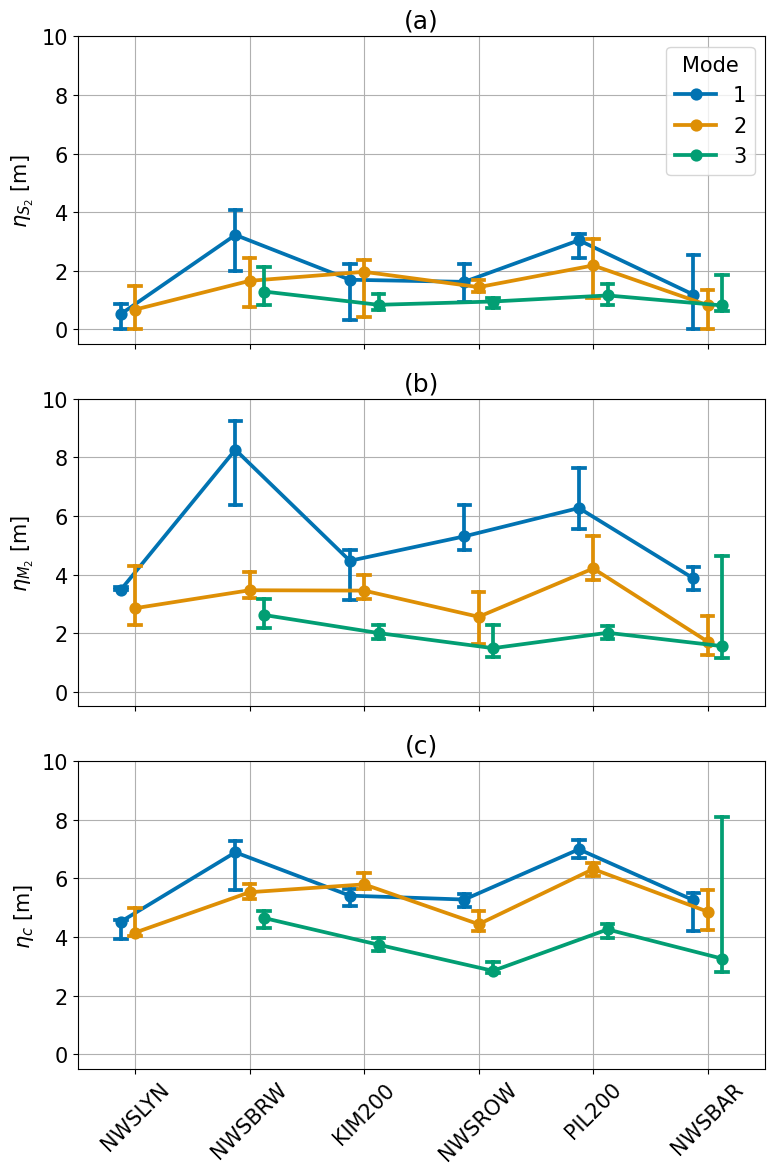

In [50]:
importlib.reload(Plot_figure)
# Parameters and units
parameters = ['η_S_2','η_M_2','η_c']
parameter_units = ['m', 'm','m']
cols = 1
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(8,12), sharex='col')
axes = axes.flatten()
# --- Plotting ---
figure_order = [list(string.ascii_lowercase)[i % 26] for i in range(len(parameters))]
for i, (param, unit) in enumerate(zip(parameters, parameter_units)):
    Plot_figure.Plot_parameter_medium_sns(axes[i], df_sites, param, unit,)
    axes[i].set_title(f"({figure_order[i]})")
    axes[i].set_xlabel("")
    axes[i].set_ylim(-0.5,10)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), title="Mode",loc='upper right') 
plt.tight_layout()
plt.savefig('NPL Aamplitude variability with mode.pdf', bbox_inches='tight')
plt.show()

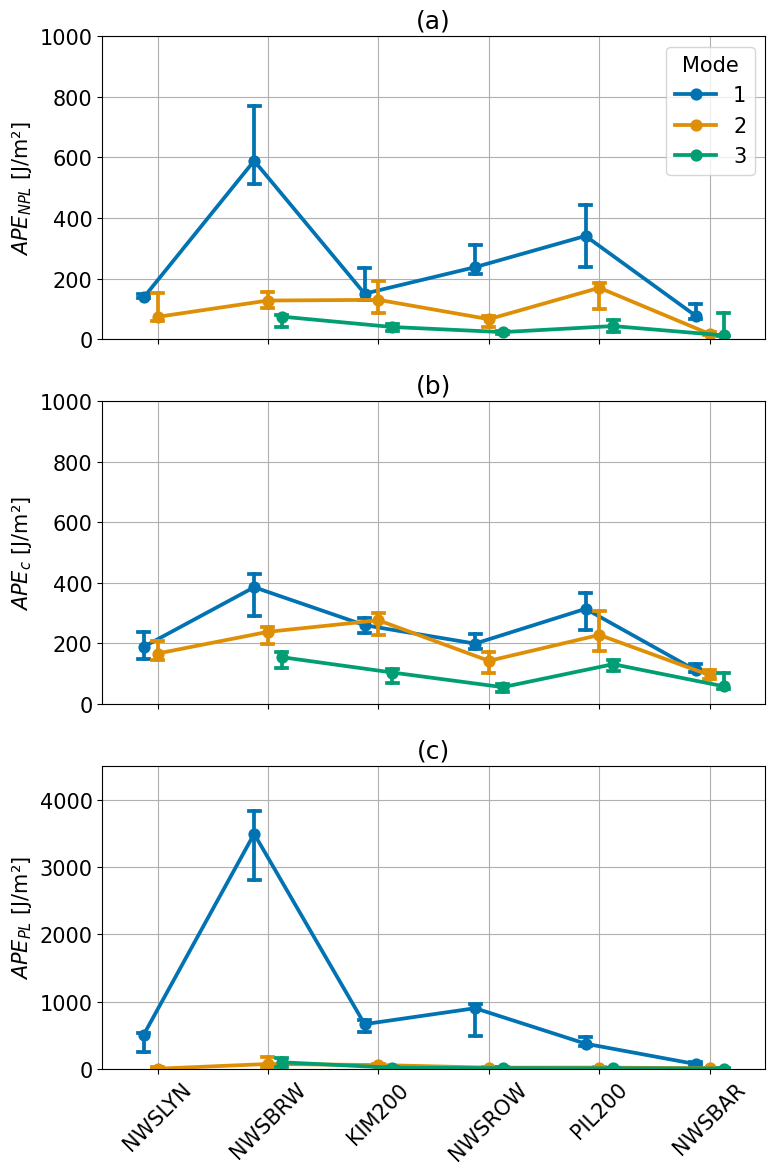

In [51]:
importlib.reload(Plot_figure)
# Parameters and units
parameters = ['APE_NPL','APE_c','APE_PL',]
parameter_units = ['J/m²','J/m²','J/m²', 'J/m²']
cols = 1
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(8,12), sharex=True)
axes = axes.flatten()
figure_order = [list(string.ascii_lowercase)[i % 26] for i in range(len(parameters))]
for i, (param, unit) in enumerate(zip(parameters, parameter_units)):
    Plot_figure.Plot_parameter_medium_sns(axes[i], df_sites, param, unit,)
    axes[i].set_title(f"({figure_order[i]})")
    axes[i].set_xlabel("")
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), title="Mode")
axes[0].set_ylim(-0.5,1000)
axes[1].set_ylim(-0.5,1000)
axes[2].set_ylim(-0.5,4500)

plt.tight_layout()
plt.savefig('APE variability with mode.pdf', bbox_inches='tight')
plt.show()

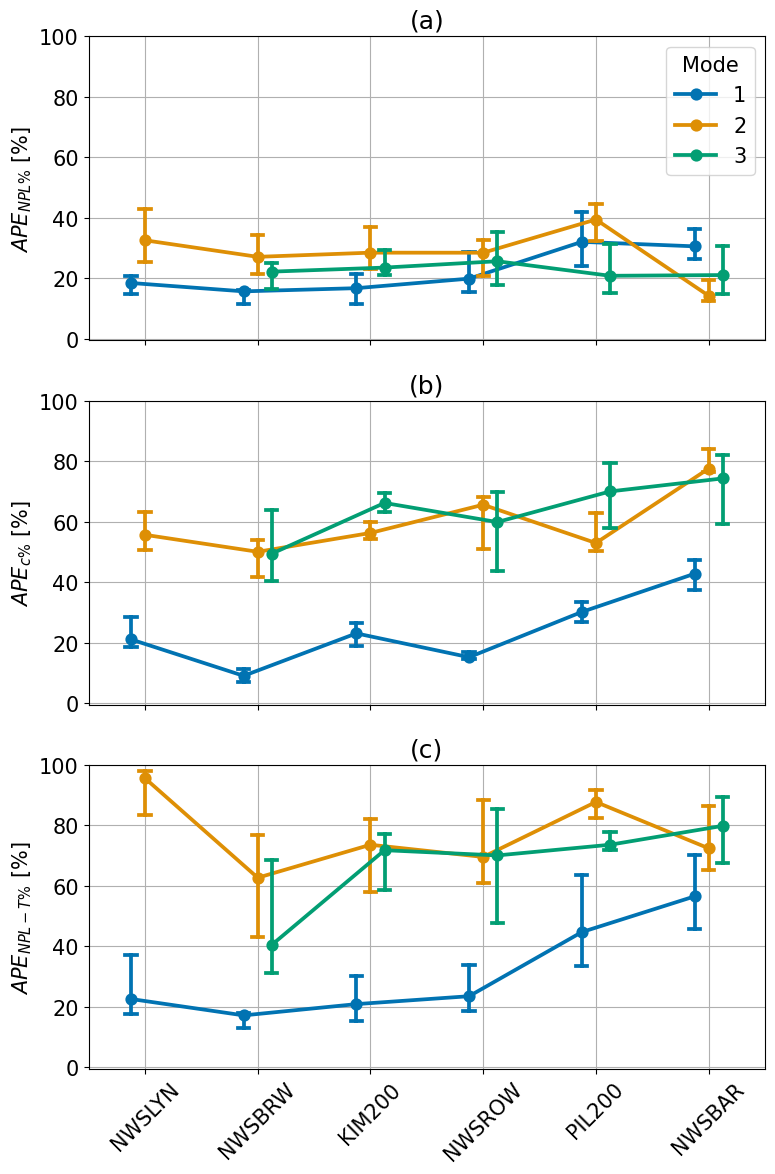

In [52]:
importlib.reload(Plot_figure)
# Parameters and units
parameters = ['APE_NPL\%','APE_c\%','APE_NPL-T\%',]
parameter_units = ['%','%','%', ]
cols = 1
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(8,12), sharex=True)
axes = axes.flatten()
figure_order = [list(string.ascii_lowercase)[i % 26] for i in range(len(parameters))]
for i, (param, unit) in enumerate(zip(parameters, parameter_units)):
    Plot_figure.Plot_parameter_medium_sns(axes[i], df_sites, param, unit,)
    axes[i].set_title(f"({figure_order[i]})")
    axes[i].set_xlabel("")
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), title="Mode",loc='upper right') 
axes[0].set_ylim(-0.5,100)
axes[1].set_ylim(-0.5,100)
axes[2].set_ylim(-0.5,100)

plt.tight_layout()
plt.savefig('APE percentage variability with mode.pdf', bbox_inches='tight')
plt.show()

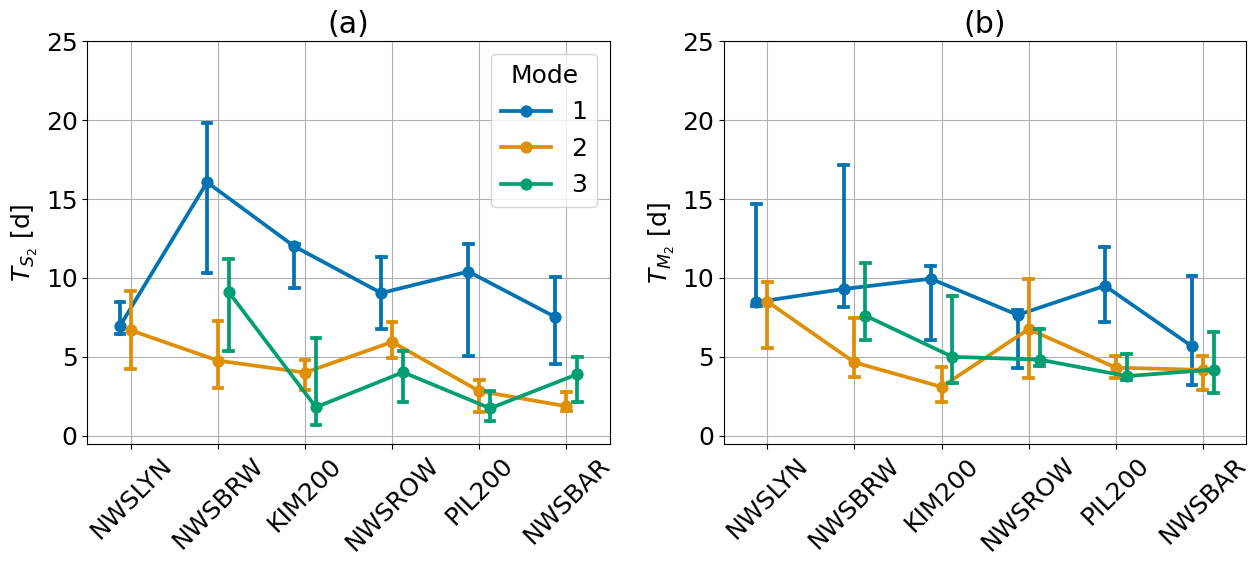

In [53]:
importlib.reload(Plot_figure)
# Parameters and units
plt.rcParams['font.size'] = 18
parameters = ['T_S_2','T_M_2']
parameter_units = ['d','d']
cols = 2
rows = len(parameters) // cols
fig, axes = plt.subplots(rows, cols, figsize=(13,6), sharex=True)
axes = axes.flatten()
figure_order = [list(string.ascii_lowercase)[i % 26] for i in range(len(parameters))]

for i, (param, unit) in enumerate(zip(parameters, parameter_units)):
    Plot_figure.Plot_parameter_medium_sns(axes[i], df_sites, param, unit,)
    axes[i].set_title(f"({figure_order[i]})")
    axes[i].set_xlabel("")
    axes[i].set_ylim(-0.5,25)
    
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles)) 
axes[0].legend(by_label.values(), by_label.keys(), title="Mode", )   
plt.tight_layout()
plt.savefig('Timescale variability with mode.pdf', bbox_inches='tight')
plt.show()

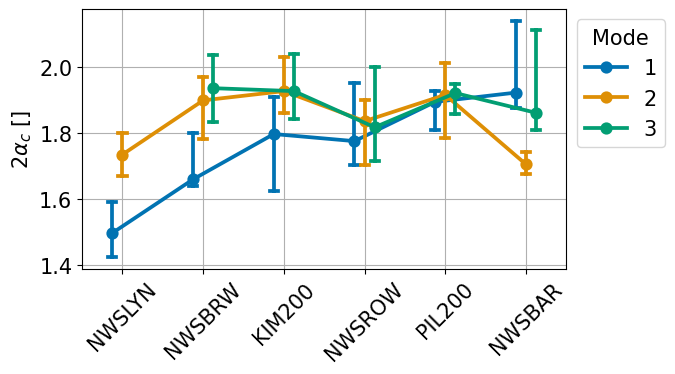

In [54]:
importlib.reload(Plot_figure)
# Parameters and units
# Single parameter and unit
plt.rcParams['font.size'] = 15
param = '2α_c'
unit = ''
fig, ax = plt.subplots(figsize=(7, 4))
# Plot
Plot_figure.Plot_parameter_medium_sns(ax, df_sites, param, unit)
# ax.set_title("(a)")
ax.set_xlabel("")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Mode", bbox_to_anchor=(1, 1))   

plt.tight_layout()
plt.savefig('Slope variability with mode.pdf', bbox_inches='tight')
plt.show()


## Seasonality

In [56]:
seasons = df_sites["season"].unique()
seasons

array(['Feb-Apr', 'May-Jul', 'Aug-Oct', 'Nov-Jan'], dtype=object)

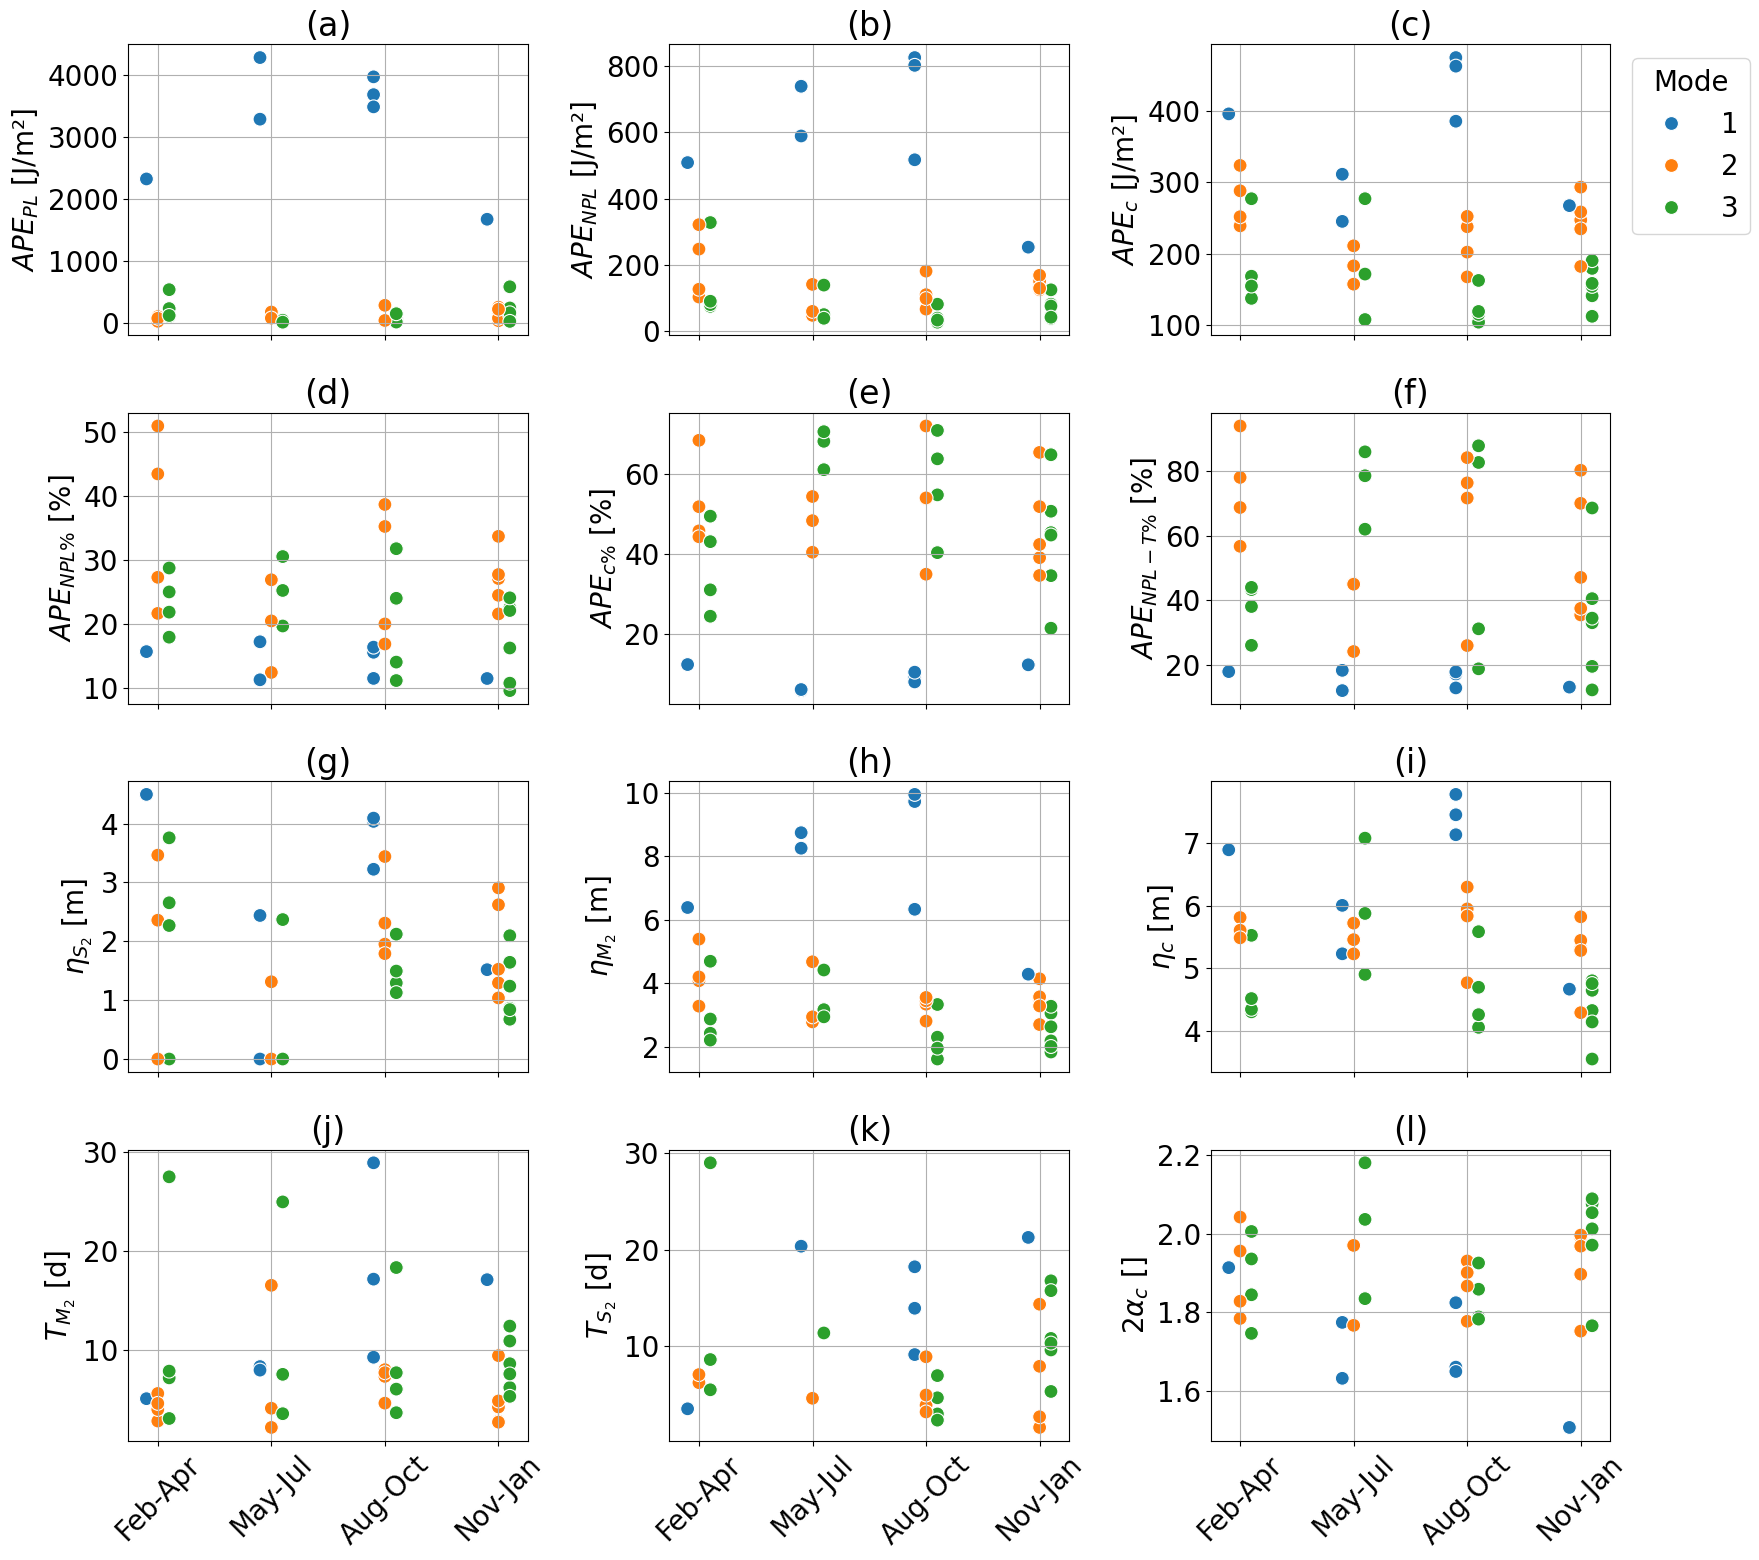

In [57]:
importlib.reload(Plot_figure)
plt.rcParams['font.size'] = 20
parameter_name = ["APE_PL","APE_NPL","APE_c",'APE_NPL\%', 'APE_c\%','APE_NPL-T\%',
                  'η_S_2','η_M_2','η_c','T_M_2', 'T_S_2','2α_c',]
parameter_units = ['J/m²','J/m²','J/m²', '%','%', '%','m','m','m','d','d',"",]
seasons = df_sites["season"].unique()
# for site_name in df_sites['Site'].unique():
for site_name in ['NWSBRW']:
    fig, axes= Plot_figure.Plot_seasonality_by_mode(df_sites,site_name,parameter_name,
                                                    parameter_units, seasons,
                                                    figsize=(6, 4))
    for ax in axes[-2:]:
        ax.set_xticks(range(len(seasons)))
        ax.set_xticklabels(seasons)
        ax.tick_params(labelbottom=True)  # ensure labels are visible
    #fig.suptitle(f"Seasonality by Mode at {site_name}", fontsize=14, y=1.02) 
    plt.tight_layout()
    fig.savefig(f"seasonality_by_mode_{site_name}.pdf",) 
    plt.show()

In [58]:
# sns.set(style="whitegrid")

# # Setup
# season_order = df_sites["season"].unique()
# season_map = {s: i for i, s in enumerate(season_order)}
# site_offset = {site: i * 0.1 for i, site in enumerate(df_sites["Site"].unique())}

# modes = sorted(df_sites["Mode"].unique())
# fig, axes = plt.subplots(len(modes), 1, figsize=(10, 3.5 * len(modes)), sharex=True)

# for i, (mode, ax) in enumerate(zip(modes, axes)):
#     df_mode = df_sites[df_sites["Mode"] == mode].copy()
#     df_mode["x"] = df_mode.apply(lambda r: season_map[r["season"]] + site_offset[r["Site"]], axis=1)
#     sns.scatterplot(data=df_mode, x="x", y="APE_η2", hue="Site", ax=ax, legend=(i == len(modes) // 2),s=80)
#     ax.set_title(f"Mode {mode}")
#     ax.set_ylabel("APE_η2 (J/m²)")
#     ax.set_xticks(list(season_map.values()))
#     ax.set_xticklabels(list(season_map.keys()))

#     legend = ax.get_legend()
#     if i != len(modes) // 2 and legend is not None:
#         legend.remove()
#     elif i == len(modes) // 2:
#         legend.set_bbox_to_anchor((1.02, 0.5))
#         legend.set_loc("center left")
#         legend.set_title("Site")

# axes[-1].set_xlabel("Season")
# plt.tight_layout()
# plt.show()
